In [63]:
import os
import torch
import numpy as np
import pandas as pd

from sklearn.neighbors import KernelDensity as KDE
from scipy.stats import ttest_ind, f_oneway
from sklearn.decomposition import PCA

from scripts.covdb.utils import load_plasma_lite, subset_plasma_lite

import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.lines import Line2D
from matplotlib.path import Path
from matplotlib.patches import Patch, PathPatch
import matplotlib.colors as mcolors
import seaborn as sns
import colorcet as cc

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
date = '2024-12-20'
sb = .1

In [3]:
cwd = os.getcwd()
os.chdir(f'{cwd}/scripts/covdb/')
plasma_lite = load_plasma_lite()
os.chdir(cwd)

In: ['B.1' 'BA.1' 'Delta' 'Omicron BA.4/5' 'Beta' 'Alpha' 'BA.2.12.1']
Out: ['B.1' 'BA.1' 'Delta' 'Omicron BA.4/5' 'Beta' 'Alpha' 'BA.2.12.1']


In [4]:
results = torch.load(f'model_covdb/results.{date}.sb{sb}.pt')
traces = results['traces']
data = results['data']

In [5]:
# Pango designation date? From https://cov-lineages.org/lineage_list.html or wikipedia
# Should really be an adult and just check GISAID...
# earliest_date = {
#     'Alpha':'2020-01-19',
#     'B.1':'2020-01-01',
#     'BA.1':'2020-06-25',
#     'BA.2':'2020-03-28',
#     'BA.5/7':'2021-12-09',
#     'Beta':'2020-08-01',
#     'Delta':'2020-10-5',
#     'Epsilon':'2020-07-01',
#     'Gamma':'2020-04-07',
#     'Iota':'2020-11-01',
#     'L452R':
#     'Lambda':
#     'Mu':
#     'Omicron BA.4/5':
#     'WT':
#     'pan-SARS-CoV-2':
#     'unknown':
earliest_date = {  # PULLED FROM GISAID (seen 10 times)
    'Alpha': '2020-01-19' ,
    'B.1': '2020-01-28' ,
    'BA.1': '2020-11-23' ,
    'BA.2': '2020-07-04' ,   # how is BA.2 being seen before BA.1...?
    'BA.5/7': '2020-07-21' ,
    'Beta': '2020-06-04' ,
    'Delta': '2020-05-01' ,
    'Epsilon': '2020-07-15' ,
    'Gamma': '2020-08-07' ,
    'Iota': '2020-12-02' ,
    'L452R': '2020-03-17' ,
    'Lambda': '2021-01-08' ,
    'Mu': '2021-02-21' ,
    'Omicron BA.4/5': '2020-07-04' ,
    'WT': '2020-01-01', #None ,
    'pan-SARS-CoV-2': None ,
    'unknown': None
}
# Convert to DataFrame for sorting
earliest_date = pd.DataFrame(list(earliest_date.items()), columns=['Pool', 'First seen date'])
earliest_date['First seen date'] = pd.to_datetime(earliest_date['First seen date'])  
earliest_date = earliest_date.sort_values('First seen date')

# Create a color palette
colormap = dict(zip(earliest_date['Pool'], sns.color_palette("nipy_spectral", len(earliest_date))))
gray = (0.5, 0.5, 0.5)
# colormap['WT'] = gray
colormap['pan-SARS-CoV-2'] = gray
colormap['unknown'] = gray

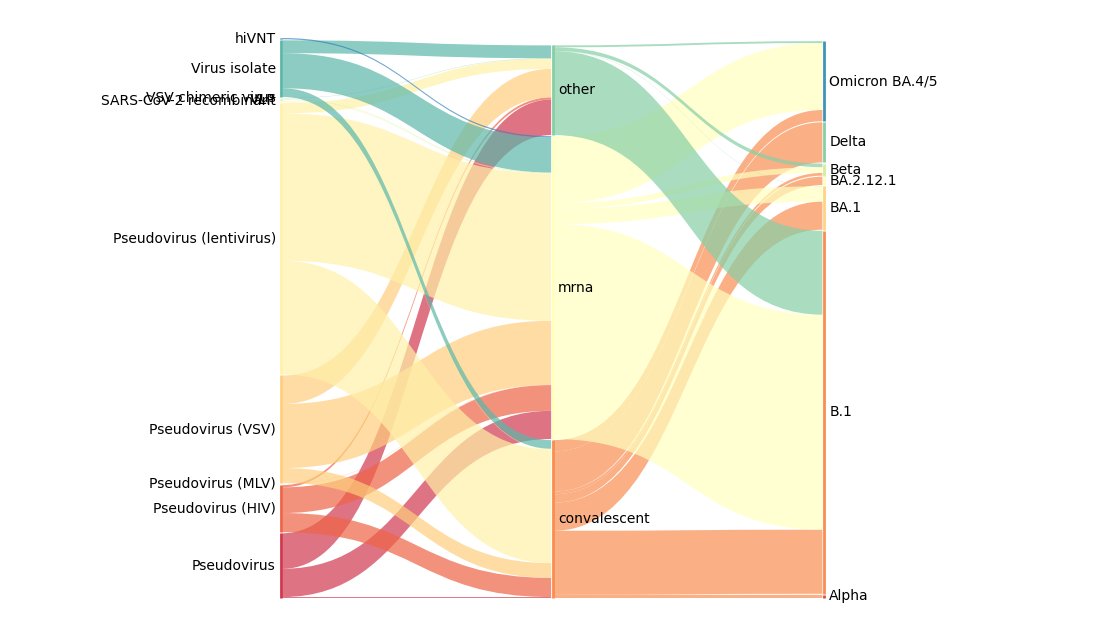

In [55]:
# Create Sankey plot showing mixing of these variables
f=10
def calc_heights(df, var, weight, buffer):
    df = df[[var, weight]].groupby(var).agg('sum')
    df['weight_plus_buffer'] = df[weight] + buffer
    df['y_start'] = df['weight_plus_buffer'].cumsum().shift(1, fill_value=0)
    df['y_end'] = df['y_start'] + df[weight]
    df = df.reset_index()
    df = df.drop(columns='weight_plus_buffer')
    return df

def draw_single_patch(y0L, y1L, y0R, y1R, color, ax, hoffset=0):
    # Let y0L be the start y-coord on the left side and let y0R be the start y-coord on the right side
    # Let y1L be the end y-coord on the left side and let y1R be the end y-coord on the right side
    xL = hoffset+0.005   # Left x anchor
    xM = hoffset+0.5  # Mid x anchor
    xR = hoffset+0.995   # Right x anchor
    verts = [(xL,y1L), (xM,y1L), (xM,y1R), (xR,y1R), (xR,y0R), (xM,y0R), (xM,y0L), (xL,y0L), (xL,y1L)]  # length = 9
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]  # length = 9
    p = Path(verts,codes)
    ax.add_patch(PathPatch(p, fc=color, ec='None', alpha=0.7))
    
def update_y_coords(row, progress, height):
    y0 = progress[row]
    y = [y0, y0+height]
    progress[row] += height
    return row, y

sankey = plasma_lite.copy()
sankey_main = sankey.reset_index()[['Assay', 'Serum', 'Most recent variant', 'index']
                   ].groupby(['Assay', 'Serum', 'Most recent variant']
                   ).agg('count'
                   ).reset_index(
                   ).rename(columns={'index':'sum'}
                   ).sort_values(by=['Assay', 'Serum', 'Most recent variant']
                   ).reset_index(drop=True)

# First, set up the axes
fig, ax = plt.subplots(figsize=(14,8))
ax.set_axis_off()
ax.set_xlim([-1, 3])

###################################################################
###################################################################
###################################################################
# Left: Assay / Plasma
##################################################
space = 1
left = 'Assay'; right='Serum'
sankey_temp = sankey_main[[left, right, 'sum']].groupby([left, right]).agg('sum').reset_index()
left_bars = sankey_temp[[left, 'sum']].groupby(left).agg('sum').reset_index()
left_bars = calc_heights(left_bars, left, 'sum', 10)
left_bars['color'] = sns.color_palette('Spectral', len(left_bars))
right_bars = sankey_temp[[right, 'sum']].groupby(right).agg('sum').reset_index()
right_bars = calc_heights(right_bars, right, 'sum', 10)
right_bars['color'] = sns.color_palette('Spectral', len(right_bars))


# Draw bars
for idx, row in left_bars.iterrows():
    ax.vlines(0, row['y_start'], row['y_end'], linewidth=2, color=row['color'])
    ax.text(-0.02, (row['y_start'] + row['y_end']) / 2, row[left], fontsize=f, ha='right', va='center')
for idx, row in right_bars.iterrows():
    ax.vlines(1, row['y_start'], row['y_end'], linewidth=2, color=row['color'])
    ax.text(1.02, (row['y_start'] + row['y_end']) / 2, row[right], fontsize=f, ha='left', va='center')
    
# Draw patches
yL = [0, 0]
yR = [0, 0]
L = None
R = None
progressL = {row[left]:row['y_start'] for _, row in left_bars.iterrows()}
progressR = {row[right]:row['y_start'] for _, row in right_bars.iterrows()}
for L in left_bars[left]:
    for R in right_bars[right]:
        row = sankey_temp[(sankey_temp[left]==L) & (sankey_temp[right]==R)]
        if not row.empty:
            row = row.iloc[0]
            L, yL = update_y_coords(row[left], progressL, row['sum'])
            R, yR = update_y_coords(row[right], progressR, row['sum'])
            c = left_bars[left_bars[left]==L]['color']
            draw_single_patch(yL[0], yL[1], yR[0], yR[1], c.item(), ax, hoffset=0)
            
            
###################################################################
###################################################################
###################################################################
# Right: Plasma / Pool
##################################################
space = 1
left = 'Serum'; right='Most recent variant'
sankey_temp = sankey_main[[left, right, 'sum']].groupby([left, right]).agg('sum').reset_index()
left_bars = sankey_temp[[left, 'sum']].groupby(left).agg('sum').reset_index()
left_bars = calc_heights(left_bars, left, 'sum', 10)
left_bars['color'] = sns.color_palette('Spectral', len(left_bars))
right_bars = sankey_temp[[right, 'sum']].groupby(right).agg('sum').reset_index()
right_bars = calc_heights(right_bars, right, 'sum', 10)
right_bars['color'] = sns.color_palette('Spectral', len(right_bars))


# Draw bars
# for idx, row in left_bars.iterrows():
#     ax.vlines(1, row['y_start'], row['y_end'], linewidth=2, color=row['color'])
#     ax.text(1-0.02, (row['y_start'] + row['y_end']) / 2, row[left], fontsize=f, ha='right', va='center')
for idx, row in right_bars.iterrows():
    ax.vlines(2, row['y_start'], row['y_end'], linewidth=2, color=row['color'])
    ax.text(2.02, (row['y_start'] + row['y_end']) / 2, row[right], fontsize=f, ha='left', va='center')
    
# Draw patches
yL = [0, 0]
yR = [0, 0]
L = None
R = None
progressL = {row[left]:row['y_start'] for _, row in left_bars.iterrows()}
progressR = {row[right]:row['y_start'] for _, row in right_bars.iterrows()}
for L in left_bars[left]:
    for R in right_bars[right]:
        row = sankey_temp[(sankey_temp[left]==L) & (sankey_temp[right]==R)]
        if not row.empty:
            row = row.iloc[0]
            L, yL = update_y_coords(row[left], progressL, row['sum'])
            R, yR = update_y_coords(row[right], progressR, row['sum'])
            c = left_bars[left_bars[left]==L]['color']
            draw_single_patch(yL[0], yL[1], yR[0], yR[1], c.item(), ax, hoffset=1)
            
# fig.savefig('figs/covdb/sankey.png', dpi=150)

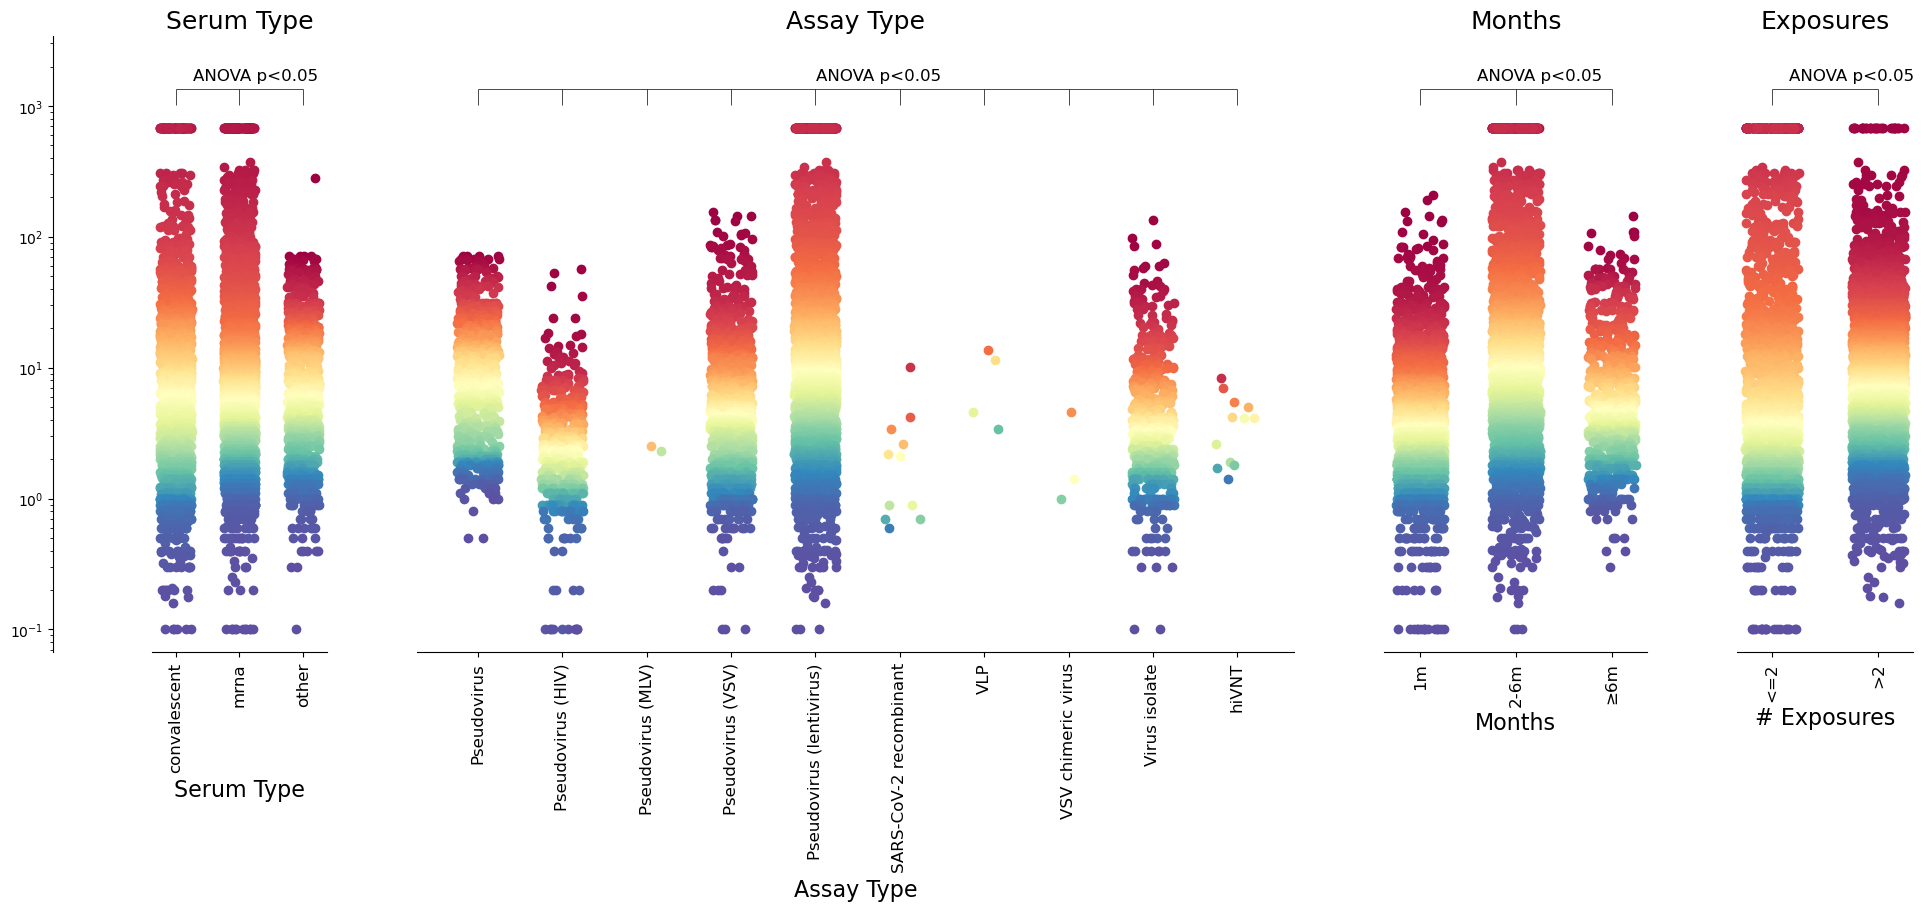

In [79]:
fig, axes = plt.subplots(1, 5, figsize=(24, 8), gridspec_kw={'width_ratios': [0.1, 2, 10, 3, 2]})

jitter_width = 0.15
space = 0.3
palette='Spectral'

miny = plasma_lite['Fold Reduction: Median'].min()
maxy = plasma_lite['Fold Reduction: Median'].max()

# First, just show Serum types
ax = axes[1]
ax.set_title('Serum Type', fontsize=18)
ax.set_xlabel('Serum Type', fontsize=16)
s = []
xticklabels = []
for x, serum in enumerate(sorted(plasma_lite['Serum'].unique())):
    temp = plasma_lite[plasma_lite['Serum']==serum].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + (x-0.5)*space
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(serum)

ax.set_xticks([(i-0.5)*space for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, rotation=90, fontsize=12)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([(i-0.5)*space for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, -0.5*space, (len(xticklabels)-1-0.5)*space,
              color='black', linewidth=0.5)
    ax.text(((len(xticklabels)-1)-0.5)*space/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')


    
# Next, just show Assay types
ax = axes[2]
ax.set_title('Assay Type', fontsize=18)
ax.set_xlabel('Assay Type', fontsize=16)
s = []
xticklabels = []
for x, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
    temp = plasma_lite[plasma_lite['Assay']==assay].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + (x-0.5)*space
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(assay)

ax.set_xticks([(i-0.5)*space for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, rotation=90, fontsize=12)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([(i-0.5)*space for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, -0.5*space, (len(xticklabels)-1-0.5)*space,
              color='black', linewidth=0.5)
    ax.text(((len(xticklabels)-1)-0.5)*space/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')

    
    
# Show Months
ax = axes[3]
ax.set_title('Months', fontsize=18)
ax.set_xlabel('Months', fontsize=16)
s = []
xticklabels = []
for x, month in enumerate(sorted(plasma_lite['Months'].unique())):
    temp = plasma_lite[plasma_lite['Months']==month].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + (x-0.5)*space
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(month)
    
ax.set_xticks([(i-0.5)*space for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, rotation=90, fontsize=12)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([(i-0.5)*space for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, -0.5*space, (len(xticklabels)-1-0.5)*space,
              color='black', linewidth=0.5)
    ax.text(((len(xticklabels)-1)-0.5)*space/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    

# Show Exposures
ax = axes[4]
ax.set_title('Exposures', fontsize=18)
ax.set_xlabel('# Exposures', fontsize=16)
s = []
xticklabels = []
for x, exposures in enumerate(sorted(plasma_lite['Exposures'].unique())):
    temp = plasma_lite[plasma_lite['Exposures']==exposures].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + (x-0.5)*space
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(exposures)
    
ax.set_xticks([(i-0.5)*space for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, rotation=90, fontsize=12)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([(i-0.5)*space for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, -0.5*space, (len(xticklabels)-1-0.5)*space,
              color='black', linewidth=0.5)
    ax.text(((len(xticklabels)-1)-0.5)*space/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')


# Format leftmost (reference) axis:
ax = axes[0]
ax.set_yscale('log')
ax.set_ylim([miny/1.5,
             maxy*5])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.set_xticks([], minor=True)
ax.set_xticks([], minor=False)
# Format plotted axes
for ax in axes[1:]:
    ax.set_yscale('log')
    ax.set_ylim([miny/1.5,
                 maxy*5])
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_yticks([], minor=True)
    ax.set_yticks([], minor=False)
    
fig.subplots_adjust(wspace=0.3)
    
fig.savefig('figs/covdb/database_diversity_effects.png', dpi=150);

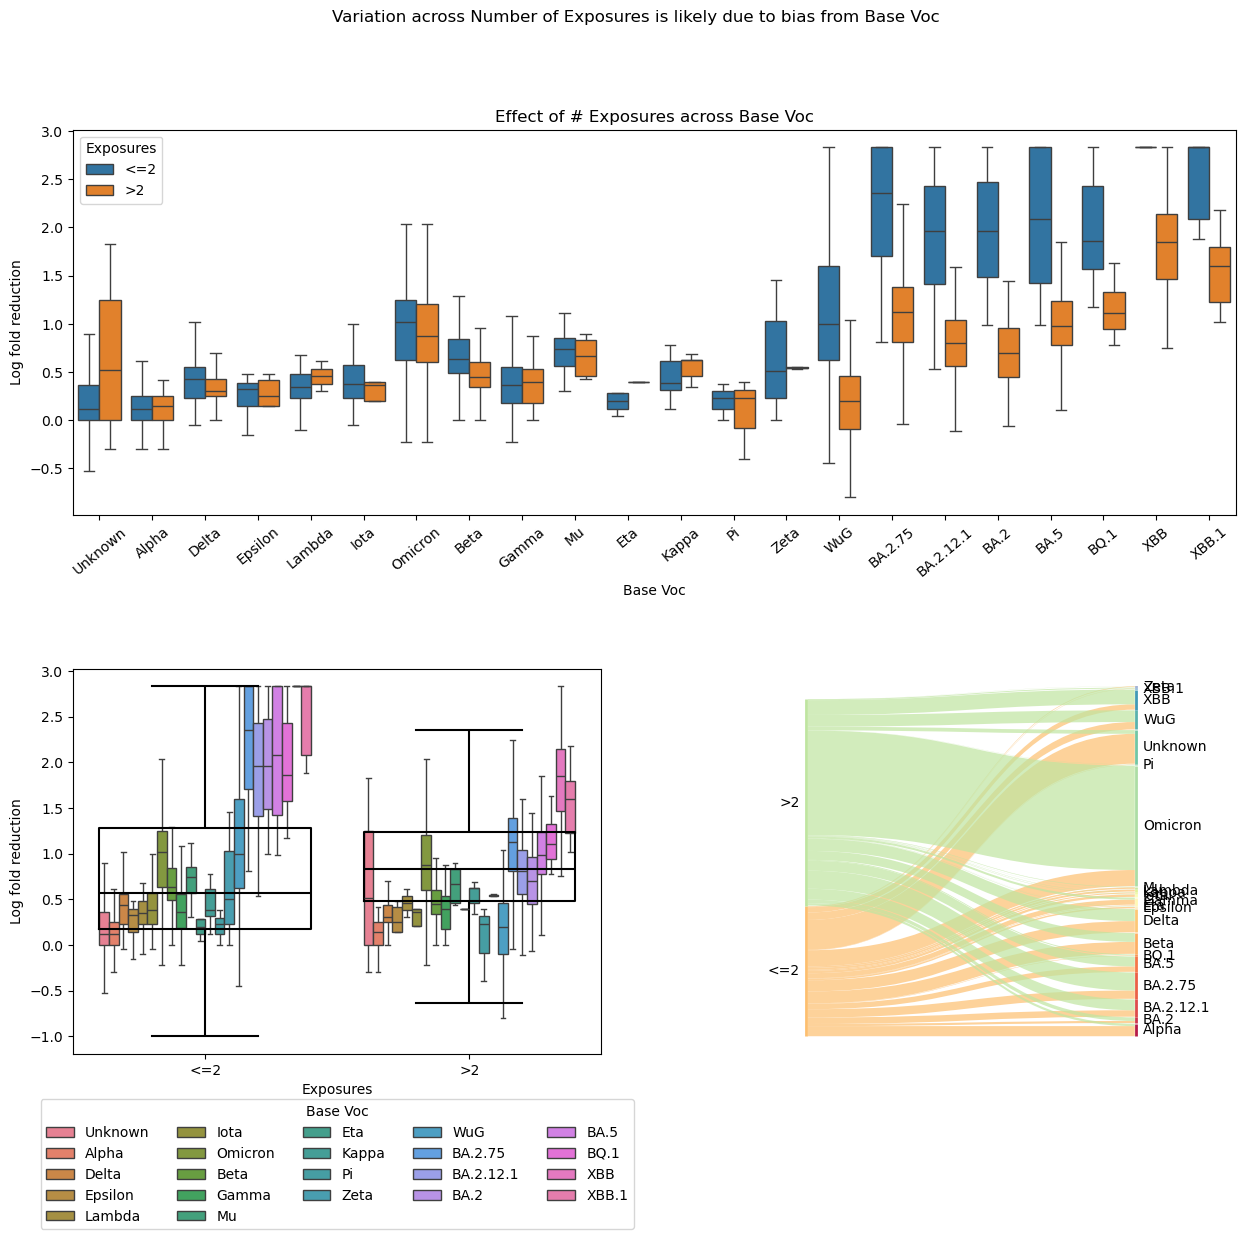

In [77]:
fig = plt.figure(figsize=(15, 12))
fig.suptitle('Variation across Number of Exposures is likely due to bias from Base Voc');

gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

ax = fig.add_subplot(gs[0, :])
ax.set_title('Effect of # Exposures across Base Voc')
sns.boxplot(x='Base Voc',
            y='Log fold reduction',
            hue='Exposures',
            showfliers=False,
            data=plasma_lite,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40);


ax = fig.add_subplot(gs[1, 0])
sns.boxplot(x='Exposures',
              y='Log fold reduction',
              hue='Base Voc',
              data=plasma_lite,
              # dodge=True,
              showfliers=False,
              ax=ax)
sns.boxplot(x='Exposures',
            y='Log fold reduction',
            data=plasma_lite,
            fill=False,
            color='k',
            showfliers=False,
            ax=ax)
ax.legend(bbox_to_anchor=(0.5, -0.1), ncol=5, loc='upper center', title='Base Voc');


ax = fig.add_subplot(gs[1,1])
# Sankey
sankey = plasma_lite.copy()
sankey_main = sankey.reset_index()[['Exposures', 'Base Voc', 'index']
                   ].groupby(['Exposures', 'Base Voc']
                   ).agg('count'
                   ).reset_index(
                   ).rename(columns={'index':'sum'}
                   ).sort_values(by=['Exposures', 'Base Voc']
                   ).reset_index(drop=True)

ax.set_xlim([-0.3, 1.3])
ax.set_axis_off()
##################################################
space = 1
left = 'Exposures'; right='Base Voc'
sankey_temp = sankey_main[[left, right, 'sum']].groupby([left, right]).agg('sum').reset_index()
left_bars = sankey_temp[[left, 'sum']].groupby(left).agg('sum').reset_index()
left_bars = calc_heights(left_bars, left, 'sum', 10)
left_bars['color'] = sns.color_palette('Spectral', len(left_bars))
right_bars = sankey_temp[[right, 'sum']].groupby(right).agg('sum').reset_index()
right_bars = calc_heights(right_bars, right, 'sum', 10)
right_bars['color'] = sns.color_palette('Spectral', len(right_bars))


# Draw bars
for idx, row in left_bars.iterrows():
    ax.vlines(0, row['y_start'], row['y_end'], linewidth=2, color=row['color'])
    ax.text(-0.02, (row['y_start'] + row['y_end']) / 2, row[left], fontsize=f, ha='right', va='center')
for idx, row in right_bars.iterrows():
    ax.vlines(1, row['y_start'], row['y_end'], linewidth=2, color=row['color'])
    ax.text(1.02, (row['y_start'] + row['y_end']) / 2, row[right], fontsize=f, ha='left', va='center')
    
# Draw patches
yL = [0, 0]
yR = [0, 0]
L = None
R = None
progressL = {row[left]:row['y_start'] for _, row in left_bars.iterrows()}
progressR = {row[right]:row['y_start'] for _, row in right_bars.iterrows()}
for L in left_bars[left]:
    for R in right_bars[right]:
        row = sankey_temp[(sankey_temp[left]==L) & (sankey_temp[right]==R)]
        if not row.empty:
            row = row.iloc[0]
            L, yL = update_y_coords(row[left], progressL, row['sum'])
            R, yR = update_y_coords(row[right], progressR, row['sum'])
            c = left_bars[left_bars[left]==L]['color']
            draw_single_patch(yL[0], yL[1], yR[0], yR[1], c.item(), ax, hoffset=0)
            
fig.subplots_adjust(hspace=0.4);

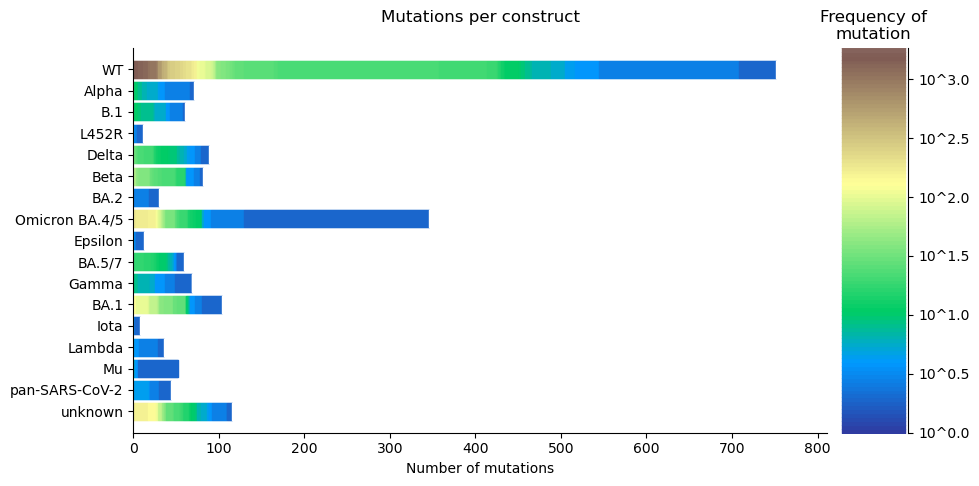

In [9]:
indices = torch.tensor(data['pools'])
one_hot = torch.nn.functional.one_hot(indices, num_classes=max(indices)+1).float()  # Shape: (3, num_classes)
mut_by_pool = data['X'].transpose(0, 1) @ one_hot

mut_by_pool_df = pd.DataFrame(index=data['features'], columns=data['pools_map'], data=mut_by_pool)
log_mut_by_pool_df = np.log10(mut_by_pool_df.replace(0, np.nan))


fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios':[10,1]})

def plot_col(y, col, palette, width, scale, ax):
    pool = col.name
    col = col.copy()
    col.name='count'
    col = col.dropna().sort_values(ascending=False).reset_index()
    for x, row in col.iterrows():
        ax.fill_between([x, x+1], 
                        y-width/2, y+width/2,
                        color=palette[int(row['count']*scale)])

ax = axes[0]

yticklabels = []
width = 0.8
scale = 30
palette_cutoff_factor = 1.3
###### Multiply by palette cutoff factor to offset terrain palette because we don't want the colors at the end
palette = sns.color_palette('terrain', int(palette_cutoff_factor*log_mut_by_pool_df.fillna(0).values.max()*scale)+2)
######
palette[0] = (1, 1, 1)  # make sure 0 counts are not shown
for y, col in enumerate(earliest_date['Pool']):
    plot_col(y, log_mut_by_pool_df[col], palette, width, scale, ax)
    yticklabels.append(col)

ax.set_yticks([i for i in range(len(yticklabels))]);
ax.set_yticklabels(yticklabels);
ax.set_ylim([len(yticklabels), -1]);
ax.set_xlim([0, ax.get_xlim()[1]]);
ax.set_xlabel('Number of mutations');
ax.spines[['right', 'top']].set_visible(False);
ax.set_title('Mutations per construct\n')


# Colorbar
ax = axes[1]
ax.set_title('Frequency of\nmutation')
arr = [i for i in range(int(scale * log_mut_by_pool_df.fillna(0).values.min()), 
                        int(scale * log_mut_by_pool_df.fillna(0).values.max() + 1) + 1)]
for i, a in enumerate(arr):
    ax.fill_between([0, 1], i, i+1, color=palette[i])
ax.set_xticks([])
yticks = np.arange(1,len(arr)+1,0.5*scale)
yticklabels = [f"10^{(tick/scale):.1f}" for tick in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.set_ylim([arr[1], arr[-1]])
ax.yaxis.set_ticks_position('right');
ax.spines[['left', 'top', 'bottom']].set_visible(False);

fig.subplots_adjust(wspace=0.03);

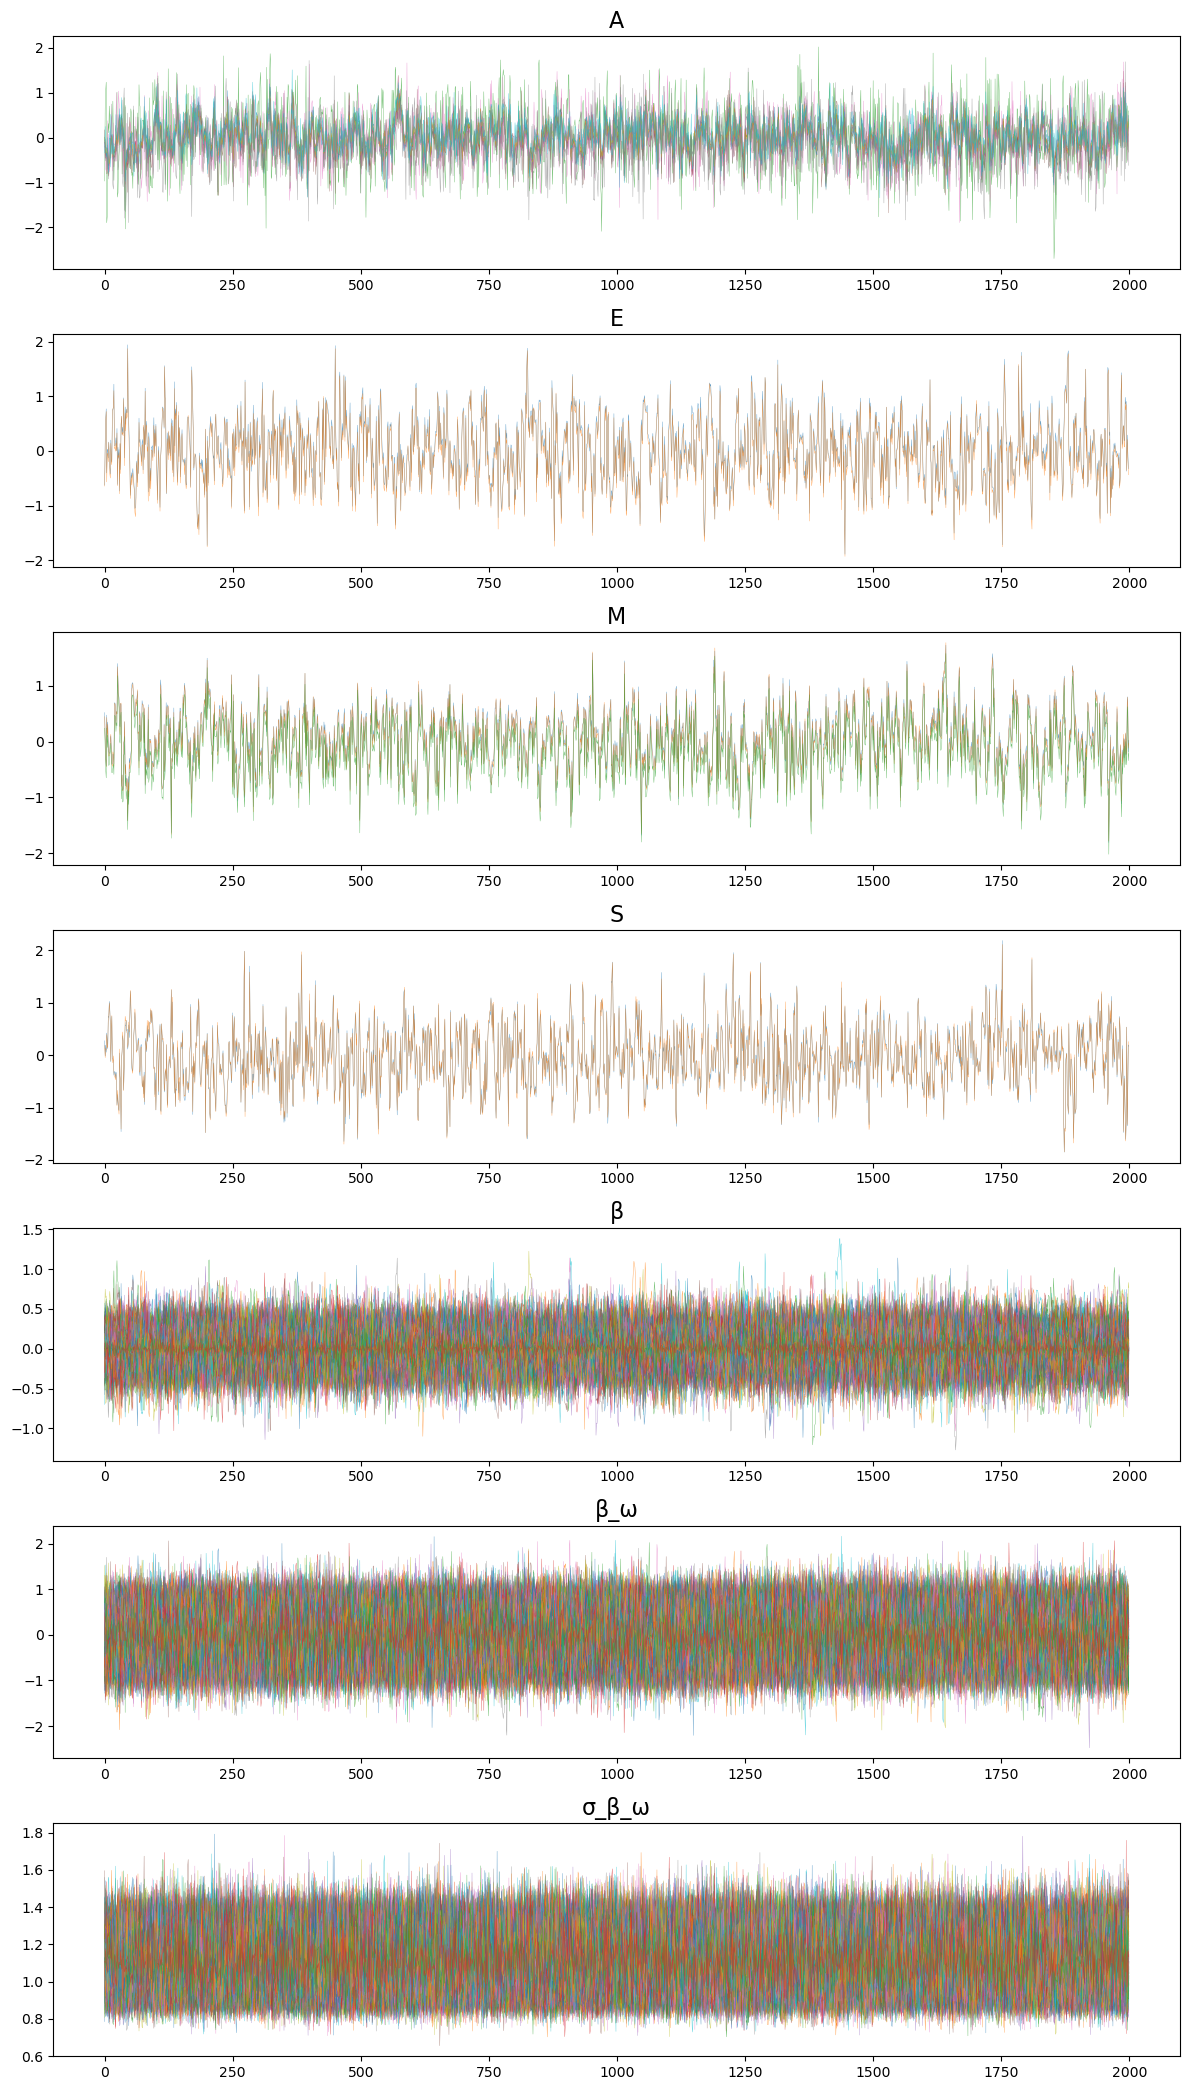

In [81]:
n_latents = len(traces.keys())
fig, axes = plt.subplots(n_latents, 1, figsize=(12, 3*n_latents))

for ax, latent in zip(axes, sorted(traces.keys())):
    trace = traces[latent]# torch.stack(traces[latent])
    if len(trace.shape) == 3:
        trace = trace.mean(dim=-2)
        for subsample in range(trace.shape[-1]):
                ax.plot(trace[:, subsample], alpha=0.7, linewidth=0.3)
    elif len(trace.shape) == 2:
        for subsample in range(trace.shape[-1]):
            ax.plot(trace[:, subsample], alpha=0.7, linewidth=0.3)
    else:
        ax.plot(trace, alpha=0.7)
        if latent == 'ELBO':
            ax.set_yscale('log');

    ax.set_title(latent, fontsize=16)

fig.tight_layout()
fig.savefig(f'figs/covdb/svi_traces_{date}.png')

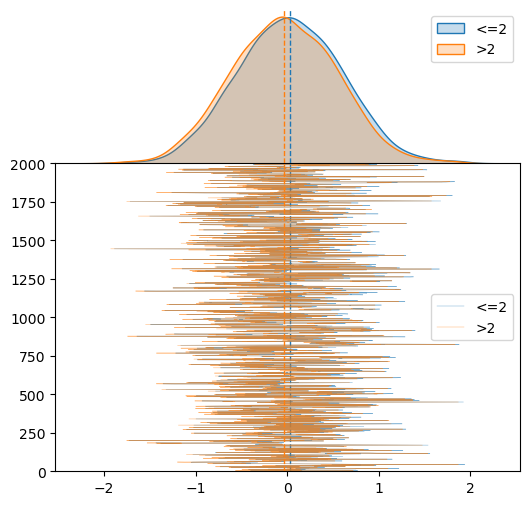

In [133]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), gridspec_kw={'height_ratios':[1,2]})
colors = ['tab:blue', 'tab:orange']

for i, ex in enumerate(data['exposures_map']):
    t = traces['E'][:, i]
    c = colors[i]
    mean = t.mean()
    # Trace plot on left axis
    axes[1].plot(t, [i for i in range(len(t))], linewidth=0.3, color=c, alpha=0.7, label=ex)
    # Show mean
    axes[1].vlines(mean, 0, len(t), color=c, linestyle='--', linewidth=1)
    # Plot KDE on right axis
    sns.kdeplot(t, ax=axes[0], fill=True, color=c, label=ex)
    # Show mean
    ax2 = axes[0].twinx()
    ax2.axis('off')
    ax2.vlines(mean, 0, 1, color=c, linestyle='--', linewidth=1)
    ax2.set_ylim([0,1])
    
    
xlim = [min([ax.get_xlim()[0] for ax in axes]), max([ax.get_xlim()[1] for ax in axes])]
for ax in axes:
    ax.set_xlim(xlim)
    ax.legend();

axes[1].set_ylim([0, traces['E'].shape[0]]);
axes[0].axis('off')
fig.subplots_adjust(hspace=0.001)

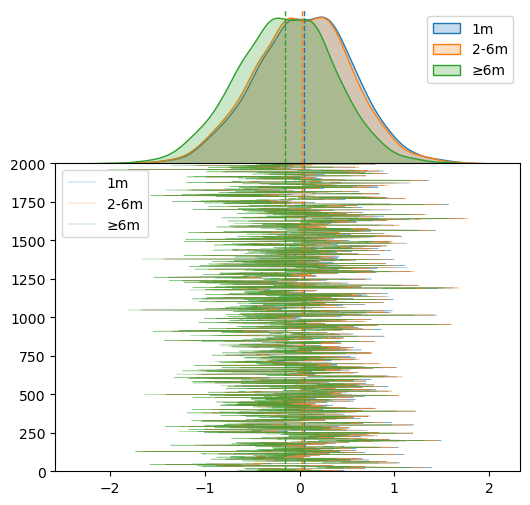

In [132]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), gridspec_kw={'height_ratios':[1,2]})
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, ex in enumerate(data['months_map']):
    t = traces['M'][:, i]
    c = colors[i]
    mean = t.mean()
    # Trace plot on left axis
    axes[1].plot(t, [i for i in range(len(t))], linewidth=0.3, color=c, alpha=0.7, label=ex)
    # Show mean
    axes[1].vlines(mean, 0, len(t), color=c, linestyle='--', linewidth=1)
    # Plot KDE on right axis
    sns.kdeplot(t, ax=axes[0], fill=True, color=c, label=ex)
    # Show mean
    ax2 = axes[0].twinx()
    ax2.axis('off')
    ax2.vlines(mean, 0, 1, color=c, linestyle='--', linewidth=1)
    ax2.set_ylim([0,1])
    
    
xlim = [min([ax.get_xlim()[0] for ax in axes]), max([ax.get_xlim()[1] for ax in axes])]
for ax in axes:
    ax.set_xlim(xlim)
    ax.legend();

axes[1].set_ylim([0, traces['M'].shape[0]]);
axes[0].axis('off')
fig.subplots_adjust(hspace=0.001)

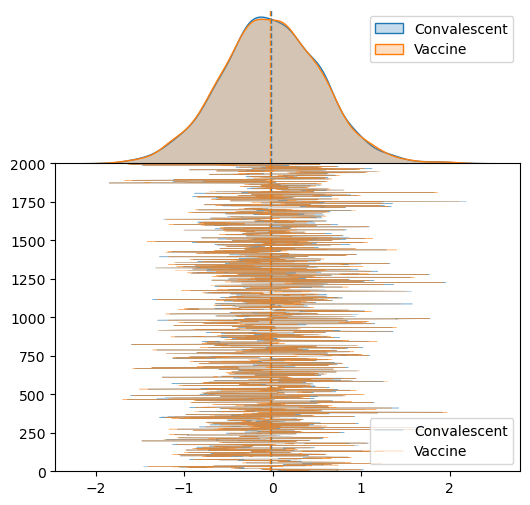

In [136]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), gridspec_kw={'height_ratios':[1,2]})
colors = ['tab:blue', 'tab:orange']

for i, ex in enumerate(data['serum_type_map']):
    t = traces['S'][:, i]
    c = colors[i]
    mean = t.mean()
    # Trace plot on left axis
    axes[1].plot(t, [i for i in range(len(t))], linewidth=0.3, color=c, alpha=0.7, label=ex)
    # Show mean
    axes[1].vlines(mean, 0, len(t), color=c, linestyle='--', linewidth=1)
    # Plot KDE on right axis
    sns.kdeplot(t, ax=axes[0], fill=True, color=c, label=ex)
    # Show mean
    ax2 = axes[0].twinx()
    ax2.axis('off')
    ax2.vlines(mean, 0, 1, color=c, linestyle='--', linewidth=1)
    ax2.set_ylim([0,1])
    
    
xlim = [min([ax.get_xlim()[0] for ax in axes]), max([ax.get_xlim()[1] for ax in axes])]
for ax in axes:
    ax.set_xlim(xlim)
    ax.legend();

axes[1].set_ylim([0, traces['S'].shape[0]]);
axes[0].axis('off')
fig.subplots_adjust(hspace=0.001)

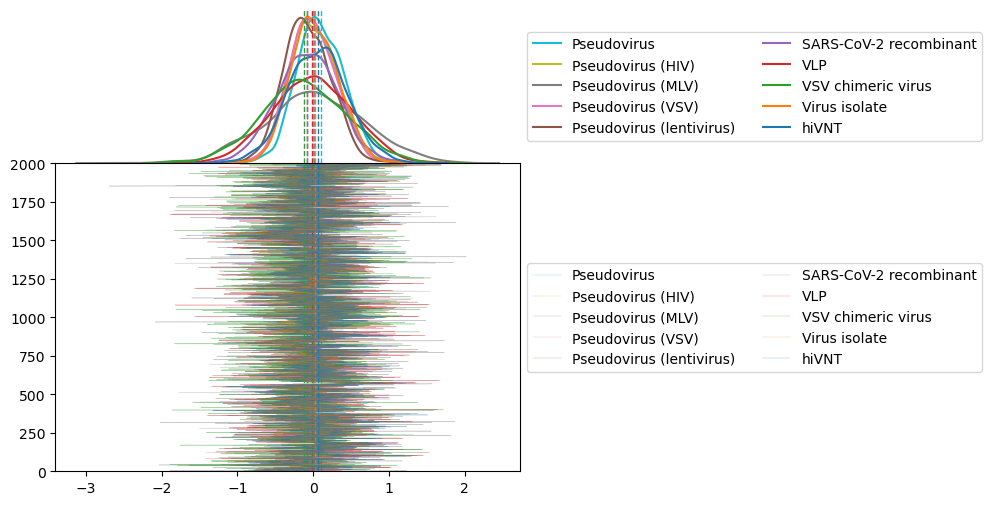

In [156]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), gridspec_kw={'height_ratios':[1,2]})
colors = sns.color_palette("tab10"); colors.reverse()

for i, ex in enumerate(data['assay_type_map']):
    t = traces['A'][:, i]
    c = colors[i]
    mean = t.mean()
    # Trace plot on left axis
    axes[1].plot(t, [i for i in range(len(t))], linewidth=0.3, color=c, alpha=0.5, label=ex)
    # Show mean
    axes[1].vlines(mean, 0, len(t), color=c, linestyle='--', linewidth=1)
    # Plot KDE on right axis
    sns.kdeplot(t, ax=axes[0], fill=False, color=c, label=ex)
    # Show mean
    ax2 = axes[0].twinx()
    ax2.axis('off')
    ax2.vlines(mean, 0, 1, color=c, linestyle='--', linewidth=1)
    ax2.set_ylim([0,1])
    
    
xlim = [min([ax.get_xlim()[0] for ax in axes]), max([ax.get_xlim()[1] for ax in axes])]
for ax in axes:
    ax.set_xlim(xlim)
    ax.legend(bbox_to_anchor=(1, 0.5), ncol=2, loc='center left');

axes[1].set_ylim([0, traces['A'].shape[0]]);
axes[0].axis('off')
fig.subplots_adjust(hspace=0.001)

In [124]:
m=traces['β'].mean(dim=0)
s=traces['β'].std(dim=0)
f=data['features']
n=data['X'].sum(dim=0)
pd.DataFrame(   {   'Mutation':fi, 
                    'N obs':ni.item(), 
                    'Mean effect':mi.item(), 
                    'Std effect':si.item()
                } for fi,ni,mi,si in zip(f,n,m,s)
            ).sort_values(by='Std effect', ascending=False
            ).to_csv('mutation_effects_stds.csv', index=False)

## Evaluate Model Fit

In [125]:
def pred_y(X, serum_type_data, assay_type_data, exposures_data, months_data, pools, β_ω, S, A, E, M):
    prediction = torch.matmul(X, β_ω.transpose(1,0))[torch.arange(X.shape[0]),pools] + \
                    S[torch.tensor(serum_type_data)] + \
                    A[torch.tensor(assay_type_data)] + \
                    E[torch.tensor(exposures_data)] + \
                    M[torch.tensor(months_data)]
    return prediction

Y_pred = pred_y(data['X'], 
                data['serum_type_data'], 
                data['assay_type_data'], 
                data['exposures_data'],
                data['months_data'],
                data['pools'], 
                results['traces']['β_ω'].mean(dim=0), 
                results['traces']['S'].mean(dim=0), 
                results['traces']['A'].mean(dim=0),
                results['traces']['E'].mean(dim=0),
                results['traces']['M'].mean(dim=0))

In [126]:
sse = sum((Y_pred - data['Y'])**2)
mse = sum((Y_pred - data['Y'])**2).sqrt() / len(data['Y'])
print('SSE: {:.2f}'.format(sse))
print('MSE: {:.4f}'.format(mse))

SSE: 325.09
MSE: 0.0046


IndexError: index 3896 is out of bounds for dimension 0 with size 3896

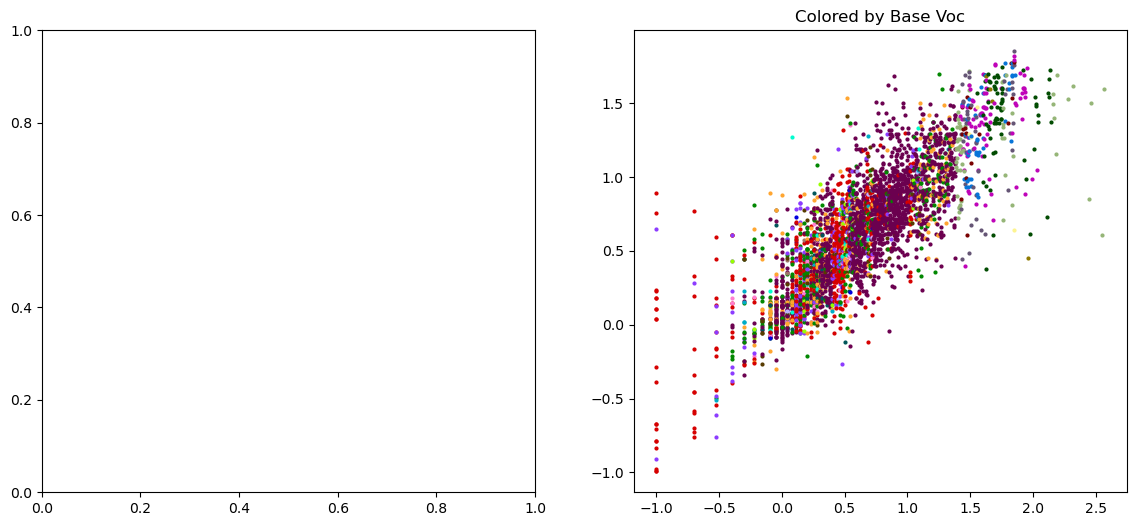

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# First plot, color by variant
ax = axes[1]
ax.set_title('Colored by Base Voc')
varns = plasma_lite['Base Voc'].unique().tolist()
palette = cc.glasbey[:len(varns)]  #sns.color_palette('tab10', len(varns))
for i, row in plasma_lite.iterrows():
    ax.plot(data['Y'][i], Y_pred[i], marker='o', markersize=2, color=palette[varns.index(row['Base Voc'])])
    
legend_elements = [Line2D([0], [0], color=color, lw=2, label=label) for color, label in zip(palette, varns)]
ax.legend(handles=legend_elements, labels=varns, fontsize=7, ncols=len(varns)/2, bbox_to_anchor=[0.5, -0.1], loc='upper center')
    
# Second plot, color by density
# ax = axes[0]
# ax.set_title('Colored by Density')
# xy = torch.stack([Y,Y_pred])
# z = gaussian_kde(xy)(xy)
# idx = z.argsort()
# x, y, z = Y[idx], Y_pred[idx], z[idx]
# ax.scatter(x, y, c=z, s=20, cmap='Spectral_r')
ax = axes[0]
ax.set_title('Colored by Most Recent Variant')
varns = plasma_lite['Most recent variant'].unique().tolist()
palette = cc.glasbey[:len(varns)]  #sns.color_palette('tab10', len(varns))
for i, row in plasma_lite.iterrows():
    ax.plot(data['Y'][i], Y_pred[i], marker='o', markersize=2, color=palette[varns.index(row['Most recent variant'])])
    
legend_elements = [Line2D([0], [0], color=color, lw=2, label=label) for color, label in zip(palette, varns)]
ax.legend(handles=legend_elements, labels=varns, fontsize=7, ncols=len(varns)/5, bbox_to_anchor=[0.5, -0.1], loc='upper center')
    
for ax in axes:
    ymin = min(data['Y'].min(), Y_pred.min())
    ymax = max(data['Y'].max(), Y_pred.max())
    yrange = ymax - ymin
    ymin -= 0.05*yrange
    ymax += 0.05*yrange
    line = np.linspace(ymin, ymax)
    ax.plot(line, line, linestyle='--')

    ax.set_xlim(ymin, ymax);
    ax.set_ylim(ymin, ymax);
    
    ax.set_xlabel('Log 10 Fold Reduction')
    ax.set_ylabel('Predicted Log 10 Fold Reduction')
    
fig.suptitle('Actual vs. Predicted Log Fold Reduction', fontsize=16);
fig.savefig(f'figs/covdb/actual_vs_predicted_{date}.png', bbox_inches='tight', dpi=150)

In [ ]:
# Dist of residuals 
residuals = data['Y'] - Y_pred

fig, axes = plt.subplots(1, 2, figsize=(9, 5), gridspec_kw={'width_ratios':[7,2]})
ax = axes[0]
# First, plot points
sns.boxplot(x=0.5,
            y=residuals,
            showfliers=False,
            boxprops={"alpha": 0.4, "facecolor":'tab:blue'},
            ax=ax)
ax.set_xticks([])
ax.set_ylabel('Residual')
ax = ax.twiny()
ax.plot([i/len(residuals) for i in range(len(residuals))], sorted(residuals), 
        marker='o', color='tab:blue', markersize=3,
        linestyle='')
ax.vlines([i/len(residuals) for i in range(len(residuals))], 0, sorted(residuals), linestyle='-', linewidth=0.2, color='tab:blue', alpha=0.4)
ax.set_xticks([])
ax.set_title('Residual plot')
ax.set_ylim([-2,2])

ax = axes[1]
sns.kdeplot(y=residuals,
            fill=True,
            ax=ax)
ax.spines[['right', 'top', 'bottom']].set_visible(False)
ax.set_xticks([])
# ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('');
ax.set_ylim(axes[0].get_ylim());

print(f'residuals std: {residuals.std().item()}')

In [ ]:
residuals_df = pd.DataFrame({'Residual':residuals,
                             'Pool':[data['pools_map'][p] for p in data['pools']],
                             'Base VoC':plasma_lite['Base Voc']})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.set_title('Residuals by Pool')
sns.kdeplot(x='Residual',
            hue='Pool',
            data=residuals_df,
            fill=True,
            ax=ax);

ax = axes[1]
ax.set_title('Residuals by Base VoC')
sns.kdeplot(x='Residual',
            hue='Base VoC',
            data=residuals_df,
            fill=True,
            ax=ax);

## Explore model results

In [ ]:
pool_effects = pd.DataFrame(columns = data['features'],
                            index = data['pools_map'],
                            data=results['traces']['β_ω'].clone().detach().mean(dim=0)
                           ).reset_index(
                           ).rename(columns={'index':'Pool'}
                           ).melt(id_vars='Pool', var_name='Mutation', value_name='Effect'
                           )

min_n = 5
pool_effects_subset = []
for _, row in pool_effects.iterrows():
    pool_idx = (data['pools_map']==row['Pool']).nonzero()[0][0]
    feat_idx = (np.array(data['features'])==row['Mutation']).nonzero()[0][0]
    num_obs = data['X'][data['pools']==pool_idx, feat_idx].sum()
    row = dict(row)
    row['N'] = int(num_obs.item())
    if num_obs > n:
        pool_effects_subset.append(row)
pool_effects_subset = pd.DataFrame(pool_effects_subset)

fig, axes = plt.subplots(1, 2, figsize=(12,24))

ax = axes[0]
ax.set_title('All pool effects')
sns.stripplot(x='Effect',
              y='Mutation',
              hue='Pool',
              palette=colormap,
              data=pool_effects.sort_values(by='Effect', ascending=True),
              ax=ax)

ax = axes[1]
ax.set_title('Pool effects with sufficient data')
sns.stripplot(x='Effect',
              y='Mutation',
              hue='Pool',
              palette=colormap,
              data=pool_effects_subset.sort_values(by='Effect', ascending=True),
              ax=ax)

for ax in axes:
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=5)

    handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles, labels, fontsize=7, bbox_to_anchor=[1,0.5], loc='center left')
    sortkey = earliest_date.sort_values(by='First seen date').reset_index(drop=True).reset_index()
    sorted_legend = sorted(zip(labels, handles), key=lambda x: sortkey[sortkey['Pool']==x[0]]['index'].item())
    sorted_labels, sorted_handles = zip(*sorted_legend)
    ax.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1,0.5), loc='center left');

In [ ]:
pool_effects_range = pool_effects[['Mutation', 'Effect']].groupby('Mutation').agg(lambda x: x.max() - x.min()).reset_index().rename(columns={'Effect':'Effect range'})
pool_effects_range = pd.merge(pool_effects, pool_effects_range, on='Mutation').sort_values(by='Effect range', ascending=False).reset_index(drop=True)

pool_effects_range_subset = pool_effects_subset[['Mutation', 'Effect']].groupby('Mutation').agg(lambda x: x.max() - x.min()).reset_index().rename(columns={'Effect':'Effect range'})
pool_effects_range_subset = pd.merge(pool_effects_subset, pool_effects_range_subset, on='Mutation').sort_values(by='Effect range', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12,44))
ax = axes[0]
sns.stripplot(x='Effect',
              y='Mutation',
              hue='Pool',
              palette=colormap,
              data=pool_effects_range,
              ax=ax)
ax = axes[1]
sns.stripplot(x='Effect',
              y='Mutation',
              hue='Pool',
              palette=colormap,
              data=pool_effects_range_subset,
              ax=ax)

for ax in axes:
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=5)

    handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles, labels, fontsize=7, bbox_to_anchor=[1,0.5], loc='center left')
    sortkey = earliest_date.sort_values(by='First seen date').reset_index(drop=True).reset_index()
    sorted_legend = sorted(zip(labels, handles), key=lambda x: sortkey[sortkey['Pool']==x[0]]['index'].item())
    sorted_labels, sorted_handles = zip(*sorted_legend)
    ax.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1,0.5), loc='center left');

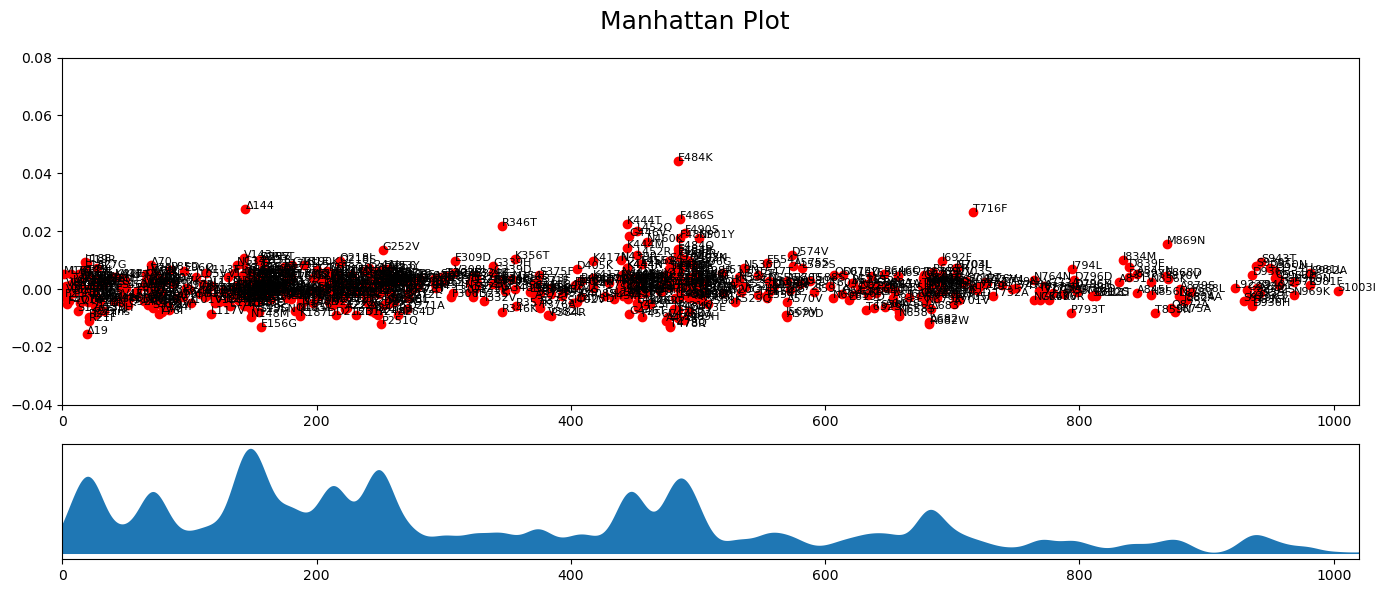

In [128]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1020]
    options['ylim'] = [-0.04, 0.08] #[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

def get_positions(mutations):
    coefficients = mutations.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return positions, coefficients

def plot_coef(ax, effects, positions, mutations, options):
    ax.plot(positions, effects, 'ro')
    
    texts = []
    for i, (pos, fea) in enumerate(zip(positions, mutations)):
        x = pos
        y = effects[i]
        text = fea #+ '\n' + '{:1.2f}'.format(y)
        texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    ylim = options['ylim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde


fig, axes, options = setup()
positions, mutations = get_positions(data['features'])
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], results['traces']['β'].mean(dim=0), positions, mutations, options)
fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()
fig.savefig(f'figs/covdb/Manhattan_{date}.png', dpi=150)

In [129]:
sns.histplot(x='Effect range',
             data=pool_effects_range[['Mutation', 'Effect range']].drop_duplicates())

NameError: name 'pool_effects_range' is not defined

In [ ]:
top_n = 50
fig, axes = plt.subplots(1, 2, figsize=(12,10))
ax = axes[0]
sns.stripplot(x='Effect',
              y='Mutation',
              hue='Pool',
              palette=colormap,
              data=pool_effects_range.merge(
                          pool_effects_range.sort_values(by='Effect range', ascending=False
                                                        ).drop_duplicates(subset=['Mutation', 'Effect range']
                                                        ).head(top_n
                                            ), on=['Mutation', 'Effect range']
                                            ).rename(columns={'Effect_x':'Effect', 'Pool_x':'Pool'}),
              ax=ax)

ax = axes[1]
sns.stripplot(x='Effect',
              y='Mutation',
              hue='Pool',
              palette=colormap,
              data=pool_effects_range_subset.merge(
                          pool_effects_range_subset.sort_values(by='Effect range', ascending=False
                                                        ).drop_duplicates(subset=['Mutation', 'Effect range']
                                                        ).head(top_n
                                            ), on=['Mutation', 'Effect range']
                                            ).rename(columns={'Effect_x':'Effect', 'Pool_x':'Pool'}),
              ax=ax)

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles, labels, fontsize=7, bbox_to_anchor=[1,0.5], loc='center left')
    sortkey = earliest_date.sort_values(by='First seen date').reset_index(drop=True).reset_index()
    sorted_legend = sorted(zip(labels, handles), key=lambda x: sortkey[sortkey['Pool']==x[0]]['index'].item())
    sorted_labels, sorted_handles = zip(*sorted_legend)
    ax.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1,0.5), loc='center left');
    
fig.tight_layout()

In [ ]:
# Calculate the avg pool specific effect
pool_specific_effects = traces['β_ω'].mean(dim=0)
pool_agnostic_effects = traces['β'].mean(dim=0)
pool_effect_differences = pool_specific_effects - pool_agnostic_effects

pool_effect_differences_df = pd.DataFrame(index=data['pools_map'],
                                          columns=data['features'],
                                          data=pool_effect_differences
                                   ).reset_index(
                                   ).melt(id_vars='index', 
                                          var_name='Mutation', 
                                          value_name='Effect difference'
                                  ).rename(columns={'index':'Pool'})
sorted_pool_effect_differences_df = pool_effect_differences_df.sort_values(by='Pool', key=lambda x: x.map({p:i for p, i in zip(sortkey['Pool'], sortkey['index'])}))

min_n = 5
sorted_pool_effect_differences_subset = []
for _, row in sorted_pool_effect_differences_df.iterrows():
    pool_idx = (data['pools_map']==row['Pool']).nonzero()[0][0]
    feat_idx = (np.array(data['features'])==row['Mutation']).nonzero()[0][0]
    num_obs = data['X'][data['pools']==pool_idx, feat_idx].sum()
    row = dict(row)
    row['N'] = int(num_obs.item())
    if num_obs > n:
        sorted_pool_effect_differences_subset.append(row)
sorted_pool_effect_differences_df_subset = pd.DataFrame(sorted_pool_effect_differences_subset).sort_values(by='Pool', key=lambda x: x.map({p:i for p, i in zip(sortkey['Pool'], sortkey['index'])}))

fig, axes = plt.subplots(1, 2, figsize=(12,5))
ax = axes[0]
ax.set_title('Effect difference')
sns.boxplot(x='Pool',
            y='Effect difference',
            hue='Pool',
            palette=colormap,
            data=sorted_pool_effect_differences_df,
            showfliers=False,
            ax=ax)
sns.stripplot(x='Pool',
              y='Effect difference',
              hue='Pool',
              palette=colormap,
              data=sorted_pool_effect_differences_df,
              jitter=True,
              ax=ax)
ax = axes[1]
ax.set_title('Effect difference - Subset')
sns.boxplot(x='Pool',
            y='Effect difference',
            hue='Pool',
            palette=colormap,
            data=sorted_pool_effect_differences_df_subset,
            showfliers=False,
            ax=ax)
sns.stripplot(x='Pool',
              y='Effect difference',
              hue='Pool',
              palette=colormap,
              data=sorted_pool_effect_differences_df_subset,
              jitter=True,
              ax=ax)
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90);

In [ ]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1020]
    options['ylim'] = [0, 1] #[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

fig, axes, options = setup()
positions, mutations = get_positions(pool_effects_range[['Mutation', 'Effect range']].drop_duplicates()['Mutation'].tolist())
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], pool_effects_range[['Mutation', 'Effect range']].drop_duplicates()['Effect range'].tolist(), positions, mutations, options)
fig.suptitle('Manhattan Plot - Effect Range', fontsize=18)
fig.tight_layout()
fig.savefig(f'figs/covdb/Manhattan_effectrange_{date}.png', dpi=150)

In [ ]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1020]
    options['ylim'] = [-0.1, 1] #[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

fig, axes, options = setup()
positions, mutations = get_positions(pool_effects_range_subset[['Mutation', 'Effect range']].drop_duplicates()['Mutation'].tolist())
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], pool_effects_range_subset[['Mutation', 'Effect range']].drop_duplicates()['Effect range'].tolist(), positions, mutations, options)
fig.suptitle('Manhattan Plot - Effect Range', fontsize=18)
fig.tight_layout()
# fig.savefig(f'figs/covdb/Manhattan_effectrange_{date}.png', dpi=150)

In [ ]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1270]
    options['ylim'] = [-0.8, .6] #[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

fig, axes, options = setup()
positions, mutations = get_positions(pool_effects_range[['Mutation', 'Effect range']].drop_duplicates()['Mutation'].tolist())
kde = plot_density(axes[1], positions, options)
temp_df = pool_effects
temp_df['Position'] = temp_df['Mutation'].apply(lambda x: positions[mutations.index(x)])
sns.scatterplot(x='Position', y='Effect', hue='Pool', palette=colormap, data=temp_df, alpha=0.7, ax=axes[0])
for _, row in temp_df[['Position', 'Mutation', 'Effect']].groupby(['Position', 'Mutation']).agg('max').reset_index().iterrows():
    if row['Effect'] > 0.2:
        axes[0].text(row['Position'], row['Effect'], row['Mutation'], fontsize=6)
for _, row in temp_df[['Position', 'Mutation', 'Effect']].groupby(['Position', 'Mutation']).agg('min').reset_index().iterrows():
    if row['Effect'] < -0.2:
        axes[0].text(row['Position'], row['Effect'], row['Mutation'], fontsize=6)
# plot_coef(axes[0], pool_effects_range[['Mutation', 'Effect range']].drop_duplicates()['Effect range'].tolist(), positions, mutations, options)

handles, labels = axes[0].get_legend_handles_labels()
# ax.legend(handles, labels, fontsize=7, bbox_to_anchor=[1,0.5], loc='center left')
sortkey = earliest_date.sort_values(by='First seen date').reset_index(drop=True).reset_index()
sorted_legend = sorted(zip(labels, handles), key=lambda x: sortkey[sortkey['Pool']==x[0]]['index'].item())
sorted_labels, sorted_handles = zip(*sorted_legend)
axes[0].legend(sorted_handles, sorted_labels, bbox_to_anchor=(1,0.5), loc='center left');


fig.suptitle('Manhattan Plot - Pool Specific Effects', fontsize=18)
fig.tight_layout()
# fig.savefig(f'figs/covdb/Manhattan_effectrange_{date}.png', dpi=150)

In [ ]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1270]
    options['ylim'] = [-0.8, .6] #[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

fig, axes, options = setup()
positions, mutations = get_positions(pool_effects_range_subset[['Mutation', 'Effect range']].drop_duplicates()['Mutation'].tolist())
kde = plot_density(axes[1], positions, options)
temp_df = pool_effects_subset
temp_df['Position'] = temp_df['Mutation'].apply(lambda x: positions[mutations.index(x)])
sns.scatterplot(x='Position', y='Effect', hue='Pool', palette=colormap, data=temp_df, alpha=0.7, ax=axes[0])
for _, row in temp_df[['Position', 'Mutation', 'Effect']].groupby(['Position', 'Mutation']).agg('max').reset_index().iterrows():
    if row['Effect'] > 0.2:
        axes[0].text(row['Position'], row['Effect'], row['Mutation'], fontsize=6)
for _, row in temp_df[['Position', 'Mutation', 'Effect']].groupby(['Position', 'Mutation']).agg('min').reset_index().iterrows():
    if row['Effect'] < -0.2:
        axes[0].text(row['Position'], row['Effect'], row['Mutation'], fontsize=6)
# plot_coef(axes[0], pool_effects_range_subset[['Mutation', 'Effect range']].drop_duplicates()['Effect range'].tolist(), positions, mutations, options)

handles, labels = axes[0].get_legend_handles_labels()
# ax.legend(handles, labels, fontsize=7, bbox_to_anchor=[1,0.5], loc='center left')
sortkey = earliest_date.sort_values(by='First seen date').reset_index(drop=True).reset_index()
sorted_legend = sorted(zip(labels, handles), key=lambda x: sortkey[sortkey['Pool']==x[0]]['index'].item())
sorted_labels, sorted_handles = zip(*sorted_legend)
axes[0].legend(sorted_handles, sorted_labels, bbox_to_anchor=(1,0.5), loc='center left');


fig.suptitle('Manhattan Plot - Pool Specific Effects', fontsize=18)
fig.tight_layout()
# fig.savefig(f'figs/covdb/Manhattan_effectrange_{date}.png', dpi=150)

In [ ]:
fig, ax = plt.subplots(figsize=(9,9))

for i, (f, s) in enumerate(zip(data['features'], results['traces']['β'].clone().detach().std(dim=0).tolist())):
    N = data['X'][:,i].sum()
    if N > 100:
        ax.plot(s, N, 'ro')
        ax.text(s, N, f, fontsize=10, ha='left', va='bottom')
    
ax.set_xlabel('Standard deviation in mutation effect')
ax.set_ylabel('Number of observations')
# results['params']['σ_β_q'].clone().detach()
fig.savefig('figs/covdb/not-volcano.png', dpi=150)

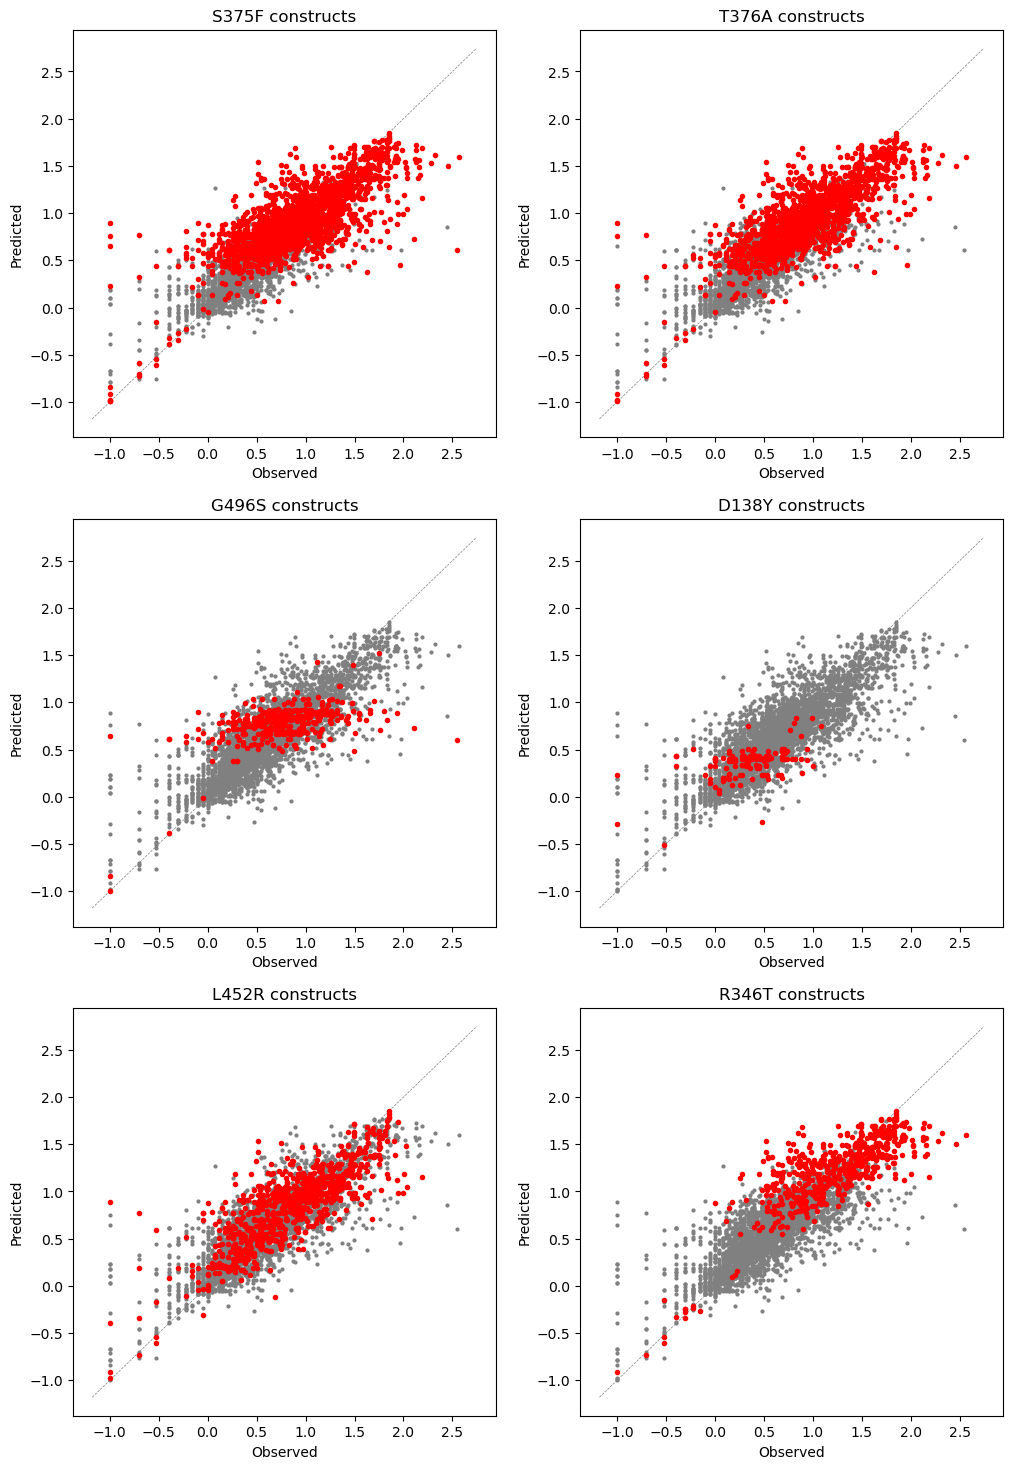

In [130]:
fig, axes = plt.subplots(3, 2, figsize=(12,18))

axes = axes.flatten()

ymin = min(data['Y'].min(), Y_pred.min())
ymax = max(data['Y'].max(), Y_pred.max())
yrange = ymax - ymin
ymin -= 0.05*yrange
ymax += 0.05*yrange
line = np.linspace(ymin, ymax)

for ax, f in zip(axes, ['S375F', 'T376A', 'G496S', 'D138Y', 'L452R', 'R346T']):
    constructs = data['X'][:, data['features'].index(f)].nonzero()
    
    ax.plot(line, line, linestyle='--', color='gray', linewidth=0.5)
    
    ax.plot(data['Y'], Y_pred, marker='o', color='gray', markersize=2, linestyle='')
    ax.plot(data['Y'][constructs], Y_pred[constructs], marker='o', color='red', markersize=3, linestyle='')
    
    ax.set_title(f'{f} constructs')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')

### Correlation to DMS

In [ ]:
xbb_escape_dms = pd.read_csv('data/Bloom/per_antibody_escape.csv') # https://www.nature.com/articles/s41586-024-07636-1
xbb_escape_dms['Mutation'] = xbb_escape_dms['wildtype'].astype(str) + xbb_escape_dms['site'].astype(str) + xbb_escape_dms['mutant'].astype(str)
xbb_escape_dms = pd.merge(xbb_escape_dms, pool_effects_range, on='Mutation', how='inner')

xbb_escape_dms_corr = xbb_escape_dms.groupby(['antibody', 'Pool']).apply(lambda x: x['escape'].corr(x['Effect'])).reset_index(name='Correlation')

heatmap_data = xbb_escape_dms_corr.pivot(index='antibody', columns='Pool', values='Correlation')
heatmap_data = heatmap_data[sorted(heatmap_data.columns, key=lambda x: earliest_date.set_index('Pool').loc[x, 'First seen date'])]

# Create the heatmap
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(heatmap_data, 
            # annot=True, 
            cmap='coolwarm', 
            cbar_kws={'label': 'Correlation'},
            vmin=-np.abs(heatmap_data).max().max(),
            vmax=np.abs(heatmap_data).max().max(),
            ax=ax)
ax.set_title('Heatmap of Correlations by Serum and Pool')
ax.set_xlabel('Pool')
ax.set_ylabel('Serum');

In [ ]:
ba12_escape_dms = pd.concat([pd.read_csv('data/Bloom/LY-CoV1404_BA1_raw_data.csv'),     # https://journals.plos.org/plospathogens/article?id=10.1371/journal.ppat.1010951#sec015
                             pd.read_csv('data/Bloom/LY-CoV1404_BA2_raw_data.csv'),
                             pd.read_csv('data/Bloom/LY-CoV1404_WH1_raw_data.csv')])
ba12_escape_dms['Mutation'] = ba12_escape_dms['wildtype'].astype(str) + ba12_escape_dms['site'].astype(str) + ba12_escape_dms['mutation'].astype(str)
ba12_escape_dms = pd.merge(ba12_escape_dms, pool_effects_range, on='Mutation', how='inner')

ba12_escape_dms_corr = ba12_escape_dms.groupby(['condition', 'Pool']).apply(lambda x: x['mut_escape'].corr(x['Effect'])).reset_index(name='Correlation')

heatmap_data = ba12_escape_dms_corr.pivot(index='condition', columns='Pool', values='Correlation')
heatmap_data = heatmap_data[sorted(heatmap_data.columns, key=lambda x: earliest_date.set_index('Pool').loc[x, 'First seen date'])]

# Create the heatmap
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(heatmap_data, 
            # annot=True, 
            cmap='coolwarm', 
            cbar_kws={'label': 'Correlation'},
            vmin=-np.abs(heatmap_data).max().max(),
            vmax=np.abs(heatmap_data).max().max(),
            ax=ax)
ax.set_title('Heatmap of Correlations by Serum and Pool')
ax.set_xlabel('Pool')
ax.set_ylabel('Serum');